In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Load the dataset
df = pd.read_csv('/content/Life Expectancy Data.csv')

african_countries = ['Algeria','Angola','Benin','Botswana','Burkina Faso',
    'Burundi','Cabo Verde','Cameroon','Central African Republic','Chad',
    'Comoros','Congo','Democratic Republic of the Congo',"Côte d'Ivoire",
    'Djibouti','Egypt','Equatorial Guinea','Eritrea','Ethiopia','Gabon',
    'Gambia','Ghana','Guinea','Guinea-Bissau','Kenya','Lesotho','Liberia',
    'Libya','Madagascar','Malawi','Mali','Mauritania','Mauritius','Morocco',
    'Mozambique','Namibia','Niger','Nigeria','Rwanda','Sao Tome and Principe',
    'Senegal','Seychelles','Sierra Leone','Somalia','South Africa','South Sudan',
    'Sudan','Swaziland','Togo','Tunisia','Uganda','United Republic of Tanzania',
    'Zambia','Zimbabwe']

df = df[df['Country'].isin(african_countries)].reset_index(drop=True)

print("shape:", df.shape)
print("\nfirst 4 rows:")
df.head(4)

shape: (864, 22)

first 4 rows:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Algeria,2015,Developing,75.6,19.0,21,NaN,0.000000,95.0,63,...,95.0,NaN,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
1,Algeria,2014,Developing,75.4,11.0,21,0.01,54.237318,95.0,0,...,95.0,7.21,95.0,0.1,547.851700,39113313.0,6.0,5.8,0.741,14.4
2,Algeria,2013,Developing,75.3,112.0,21,0.53,544.450743,95.0,25,...,95.0,7.12,95.0,0.1,5471.866766,38338562.0,5.9,5.8,0.737,14.4
3,Algeria,2012,Developing,75.1,113.0,21,0.66,555.926083,95.0,18,...,95.0,6.14,95.0,0.1,5564.825660,37565847.0,5.9,5.8,0.732,14.4


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

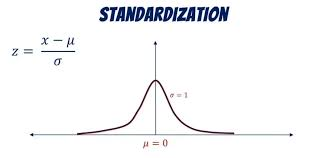


In [15]:
#encode country names to numbers
countries = df['Country'].unique()
country_map = {c: i for i, c in enumerate(countries)}
df['Country_encoded'] = df['Country'].map(country_map)

#encode Status column (Developing = 0, Developed = 1)
df['Status_encoded'] = df['Status'].map({'Developing': 0, 'Developed': 1})

#pick only numeric columns for PCA
cols = ['Country_encoded', 'Year', 'Status_encoded',
        'Life expectancy ', 'Adult Mortality', 'infant deaths',
        'Alcohol', 'percentage expenditure', 'Hepatitis B',
        'Measles ', ' BMI ', 'under-five deaths ', 'Polio',
        'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP',
        'Population', ' thinness  1-19 years', ' thinness 5-9 years',
        'Income composition of resources', 'Schooling']

data = df[cols].values

#fill missing values with column mean
col_means = np.nanmean(data, axis=0)
for j in range(data.shape[1]):
    missing = np.isnan(data[:, j])
    data[missing, j] = col_means[j]

print("missing after imputation:", np.isnan(data).sum())

#standardize: z = (x - mean) / std
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
std[std == 0] = 1

standardized_data = (data - mean) / std

print("\nStandardized data shape:", standardized_data.shape)
standardized_data[:5]

missing after imputation: 0

Standardized data shape: (864, 22)


array([[-1.70026736,  1.62697843,  0.        ,  2.12078989, -1.58247157,
        -0.28867636,  0.        , -0.50876073,  0.86782449, -0.24641004,
         2.90225851, -0.34736017,  0.89547729,  0.        ,  0.88641052,
        -0.64551126,  1.04321429,  1.79142628, -0.47316902, -0.51370032,
         1.79265982,  1.83196233],
       [-1.70026736,  1.41004798,  0.        ,  2.09582191, -1.63360734,
        -0.28867636, -0.97908857, -0.25485888,  0.86782449, -0.2502535 ,
         2.81437821, -0.34736017,  0.89547729,  0.91268092,  0.88641052,
        -0.64551126, -0.40774636,  1.74807014, -0.47316902, -0.51370032,
         1.77987349,  1.83196233],
       [-1.70026736,  1.19311752,  0.        ,  2.08333792, -0.98801824,
        -0.28867636, -0.78638745,  2.03998354,  0.86782449, -0.24872832,
         2.71850879, -0.34736017,  0.89547729,  0.86782566,  0.88641052,
        -0.64551126,  1.58520455,  1.70376845, -0.51077665, -0.51370032,
         1.75430082,  1.83196233],
       [-1.70026736

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [16]:
#covariance matrix
n = standardized_data.shape[0]
cov_matrix = (1 / (n - 1)) * (standardized_data.T @ standardized_data)

print("covariance matrix shape:", cov_matrix.shape)
cov_matrix

covariance matrix shape: (22, 22)


array([[ 1.00115875e+00, -1.82285494e-18,  0.00000000e+00,
        -8.97837133e-03,  1.86728475e-02,  5.43505602e-02,
         1.12090477e-01,  6.46396353e-02,  4.54040622e-02,
         2.51242809e-02,  1.18328856e-02,  6.21096936e-02,
         7.40171741e-02,  2.52553617e-01,  9.74885371e-02,
         2.03124206e-01, -1.22612256e-02,  6.08426260e-02,
         1.97863997e-02,  3.71668596e-02,  4.60037486e-02,
         1.02017972e-01],
       [-1.82285494e-18,  1.00115875e+00,  0.00000000e+00,
         3.32263933e-01, -9.50271931e-02, -4.38741955e-02,
        -1.56174360e-01,  8.89649759e-02,  2.29478759e-02,
        -1.34481262e-01,  1.68285784e-01, -5.92896286e-02,
         1.68240658e-01,  1.15862739e-01,  2.11817395e-01,
        -2.74318623e-01,  1.26387063e-01,  5.05154938e-02,
        -1.52548680e-01, -1.47277525e-01,  3.14268844e-01,
         2.73814931e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
    

We need to compute a covariance matrix because:
First, it captures how much features vary together, without it we would have no way of knowing which features are related and which are independent. Second, it's the actual matrix we decompose to get our eigenvalues and eigenvectors which are what define the principal components.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [17]:
#eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

#removing imaginary parts if any
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print("eigenvalues shape:", eigenvalues.shape)
print("eigenvectors shape:", eigenvectors.shape)
eigenvalues, eigenvectors

eigenvalues shape: (22,)
eigenvectors shape: (22, 22)


(array([4.71367800e+00, 2.69826470e+00, 2.30754786e+00, 1.75113803e+00,
        1.56847772e+00, 1.17771691e+00, 1.00283509e+00, 9.49929686e-01,
        2.02051281e-03, 1.12904140e-01, 1.47670803e-01, 1.62969547e-01,
        1.78504435e-01, 2.59021218e-01, 7.31656402e-01, 6.88478491e-01,
        6.92312327e-01, 4.28636383e-01, 4.39696937e-01, 5.19504044e-01,
        4.91370482e-01, 0.00000000e+00]),
 array([[-1.37070983e-02, -9.81680740e-02, -1.35236324e-01,
         -3.01717867e-01, -1.45535229e-01, -2.39279333e-01,
         -4.28581885e-01,  5.19717751e-01, -6.18466672e-03,
         -4.57328156e-03,  1.40661088e-02,  7.98330229e-02,
          1.65856087e-02, -4.33433915e-02, -1.65429282e-02,
         -4.52784926e-01,  3.35380893e-01,  5.05755962e-02,
          7.74431437e-02,  2.37807543e-02, -1.13821852e-01,
          0.00000000e+00],
        [-1.75311218e-01, -4.63450764e-02,  1.93301211e-01,
         -2.81886117e-02, -5.47424076e-02, -4.64443730e-01,
         -1.75321102e-01, -5.23

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [18]:
#sorting principal components
sorted_idx = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_idx]
sorted_eigenvectors = eigenvectors[:, sorted_idx]

print("sorted eigenvalues (top 5):")
print(sorted_eigenvalues[:5])
sorted_eigenvectors

sorted eigenvalues (top 5):
[4.713678   2.6982647  2.30754786 1.75113803 1.56847772]


array([[-1.37070983e-02, -9.81680740e-02, -1.35236324e-01,
        -3.01717867e-01, -1.45535229e-01, -2.39279333e-01,
        -4.28581885e-01,  5.19717751e-01, -1.65429282e-02,
         3.35380893e-01, -4.52784926e-01,  2.37807543e-02,
        -1.13821852e-01,  7.74431437e-02,  5.05755962e-02,
        -4.33433915e-02,  1.65856087e-02,  7.98330229e-02,
         1.40661088e-02, -4.57328156e-03, -6.18466672e-03,
         0.00000000e+00],
       [-1.75311218e-01, -4.63450764e-02,  1.93301211e-01,
        -2.81886117e-02, -5.47424076e-02, -4.64443730e-01,
        -1.75321102e-01, -5.23675888e-01, -3.12283627e-01,
        -3.48249636e-02, -2.00035604e-01, -5.03888365e-02,
        -1.28208599e-01, -3.15840277e-01,  3.63355804e-01,
        -8.70353024e-02, -9.63879146e-03, -7.67207445e-02,
        -2.85740117e-02, -3.73184206e-02,  3.02888513e-03,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
    

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [19]:
#calculate explained variance per component
total_var = np.sum(sorted_eigenvalues)
explained_var = sorted_eigenvalues / total_var
cumulative_var = np.cumsum(explained_var)

print("explained variance per component:")
for i in range(len(explained_var)):
    print(f"  PC{i+1}: {explained_var[i]*100:.2f}%  |  cumulative: {cumulative_var[i]*100:.2f}%")
    if cumulative_var[i] >= 0.95:
        break

#pick number of components that reach 95% variance
num_components = np.argmax(cumulative_var >= 0.95) + 1
print(f"\ncomponents selected: {num_components}")
print(f"variance kept: {cumulative_var[num_components-1]*100:.2f}%")

#project the data
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]

print("\nreduced data shape:", reduced_data.shape)
reduced_data[:5]

explained variance per component:
  PC1: 22.42%  |  cumulative: 22.42%
  PC2: 12.83%  |  cumulative: 35.25%
  PC3: 10.98%  |  cumulative: 46.23%
  PC4: 8.33%  |  cumulative: 54.56%
  PC5: 7.46%  |  cumulative: 62.02%
  PC6: 5.60%  |  cumulative: 67.62%
  PC7: 4.77%  |  cumulative: 72.39%
  PC8: 4.52%  |  cumulative: 76.91%
  PC9: 3.48%  |  cumulative: 80.39%
  PC10: 3.29%  |  cumulative: 83.68%
  PC11: 3.27%  |  cumulative: 86.96%
  PC12: 2.47%  |  cumulative: 89.43%
  PC13: 2.34%  |  cumulative: 91.76%
  PC14: 2.09%  |  cumulative: 93.86%
  PC15: 2.04%  |  cumulative: 95.89%

components selected: 15
variance kept: 95.89%

reduced data shape: (864, 15)


array([[-4.19123640e+00, -1.61125271e+00,  2.42615941e+00,
        -5.18159112e-02,  2.99099218e-01, -7.04155328e-01,
         1.55444259e+00, -5.24547000e-01,  8.93890051e-01,
        -4.76745189e-01,  1.50008416e+00, -5.57244081e-01,
        -1.59482035e-01, -3.19649150e-01,  1.24086576e+00],
       [-3.96058668e+00, -8.27535595e-01,  2.63760795e+00,
        -8.01072248e-01,  4.41208988e-01, -1.33389720e+00,
         1.49898647e+00, -3.07710975e-01,  1.29202254e+00,
        -1.09091751e+00,  1.63199538e+00, -7.29248332e-01,
         3.02173500e-01, -2.57005311e-01,  6.26500545e-01],
       [-4.70872316e+00, -2.16998443e+00,  1.51340669e+00,
         4.58433962e-01, -1.32614764e-01, -2.87254746e-01,
         4.54057003e-01, -1.09768072e+00,  1.98456574e+00,
        -1.28329187e+00,  9.24063131e-01, -3.93110039e-01,
         4.98401980e-01, -9.97151099e-02,  2.58761883e-01],
       [-4.62757778e+00, -2.19828641e+00,  1.50752575e+00,
         6.77950214e-01, -5.25639677e-02,  3.15607710

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [20]:
#reduced Data
print(f'original shape: {standardized_data.shape}')
print(f'reduced shape: {reduced_data.shape}')
print(f'went from {standardized_data.shape[1]} dimensions down to {reduced_data.shape[1]}')
reduced_data[:5]

original shape: (864, 22)
reduced shape: (864, 15)
went from 22 dimensions down to 15


array([[-4.19123640e+00, -1.61125271e+00,  2.42615941e+00,
        -5.18159112e-02,  2.99099218e-01, -7.04155328e-01,
         1.55444259e+00, -5.24547000e-01,  8.93890051e-01,
        -4.76745189e-01,  1.50008416e+00, -5.57244081e-01,
        -1.59482035e-01, -3.19649150e-01,  1.24086576e+00],
       [-3.96058668e+00, -8.27535595e-01,  2.63760795e+00,
        -8.01072248e-01,  4.41208988e-01, -1.33389720e+00,
         1.49898647e+00, -3.07710975e-01,  1.29202254e+00,
        -1.09091751e+00,  1.63199538e+00, -7.29248332e-01,
         3.02173500e-01, -2.57005311e-01,  6.26500545e-01],
       [-4.70872316e+00, -2.16998443e+00,  1.51340669e+00,
         4.58433962e-01, -1.32614764e-01, -2.87254746e-01,
         4.54057003e-01, -1.09768072e+00,  1.98456574e+00,
        -1.28329187e+00,  9.24063131e-01, -3.93110039e-01,
         4.98401980e-01, -9.97151099e-02,  2.58761883e-01],
       [-4.62757778e+00, -2.19828641e+00,  1.50752575e+00,
         6.77950214e-01, -5.25639677e-02,  3.15607710

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

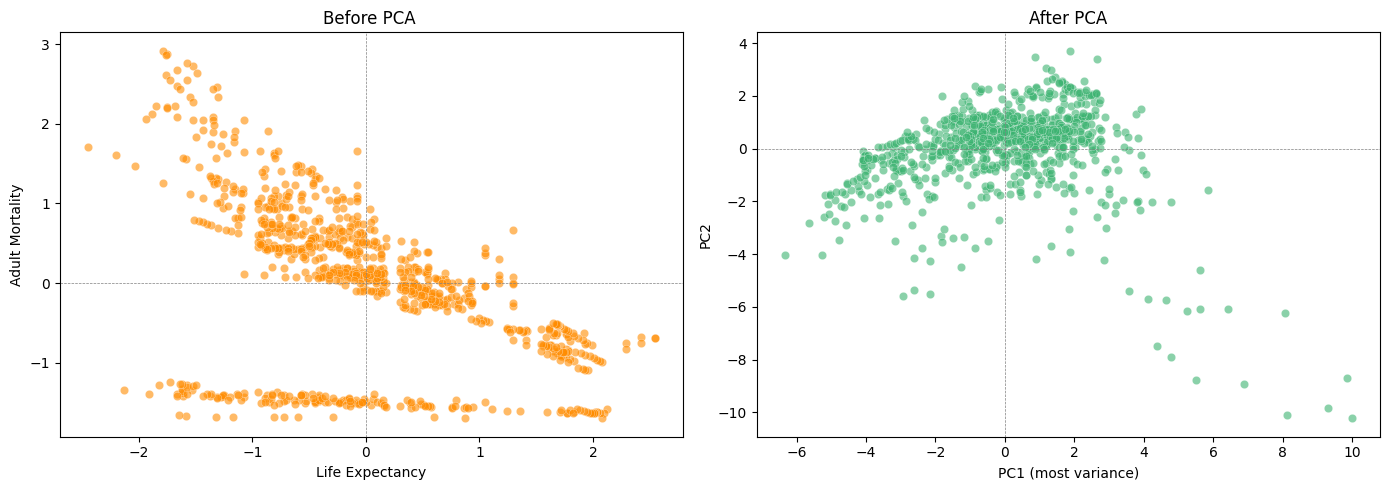

In [21]:
#before & after PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# before PCA
axes[0].scatter(standardized_data[:, 3], standardized_data[:, 4],
                alpha=0.6, color='darkorange', edgecolors='white', linewidth=0.3)
axes[0].set_title('Before PCA ')
axes[0].set_xlabel('Life Expectancy')
axes[0].set_ylabel('Adult Mortality')
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='gray', linewidth=0.5, linestyle='--')

# after PCA
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1],
                alpha=0.6, color='mediumseagreen', edgecolors='white', linewidth=0.3)
axes[1].set_title('After PCA')
axes[1].set_xlabel('PC1 (most variance)')
axes[1].set_ylabel('PC2')
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. The left plot shows that as life expectancy increases in African countries, adult mortality drops, which shows a negative relationship in the diagonal pattern. After PCA, the same 864 data points are projected onto PC1 and PC2. PC1 captures 22.42% of the variance while PC2 captures 12.83%, which confirms that PC1 has more information even if the spread looks similar due to a few extreme outlier points pulling PC2 down.


2. The code selected 15 components since they are the ones that explain 95.89% of the variance. I used 95% because it would retain almost all the important information while reducing the number of features from 22 to 15. The tradeoff is losing the remaining 4.11% which is mostly noise and minor country-specific details that are not real patterns.


3. By going from 22 to 15 dimensions, some country-specific information dissapear. Differences in health spending between similar economies like Benin and Togo get compressed together. This causes indicators used to measure population pressure like child thinness and infant mortality rates between neighbouring countries likes Niger and Mali lose their individual identity and get added to the principal components.

[Github Link](https://github.com/tdorcas-akim/PCA_group44.git)